# analysis.network-properties

In this notebook we will analyze the properties of bipartite host-organism networks

In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats
from yaml import load, Loader
from daforfer import DaforferDB
conf = load(open("conf.yaml"), Loader)
db = DaforferDB(conf['database'])
si = DaforferDB(conf['si'])
si.toc()

┌───────────────────────────────┬───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┐
│             name              │                                                        description                                                        │
│            varchar            │                                                          varchar                                                          │
├───────────────────────────────┼───────────────────────────────────────────────────────────────────────────────────────────────────────────────────────────┤
│ tablePABs                     │ This table summarizes most of the information of our detected OTUs, including host_range, site_range, habitat_range, etc. │
│ tableSiteInformation          │ Library sites and context                                                                                                 │
│ tableDivBySite                │ Site-level diversi

## Load data

We need to load both virus, bacteria and virus-bact files. For each of these ones, we need to load the null distribution file and the observed values. 

In [2]:
null_vb = pd.read_csv("scratch/bipartite.virusbact.weighted.null.csv")
null_v = pd.read_csv("scratch/bipartite.virus.weighted.null.csv")
null_b = pd.read_csv("scratch/bipartite.bact.weighted.null.csv")
null_vb['network'] = 'virus-bacteria'
null_v['network'] = 'virus'
null_b['network'] = 'bacteria'

observed_vb = pd.read_csv("scratch/bipartite.virusbact.weighted.observed.csv")
observed_v = pd.read_csv("scratch/bipartite.virus.weighted.observed.csv")
observed_b = pd.read_csv("scratch/bipartite.bact.weighted.observed.csv")
observed_vb['network'] = 'virus-bacteria'
observed_v['network'] = 'virus'
observed_b['network'] = 'bacteria'

null = pd.concat([null_vb, null_v, null_b])
observed = pd.concat([observed_vb, observed_v, observed_b])

Quick look to to the null distribution. It's a file where each row is a randomization of the original network, and the columns are the different properties

In [3]:
null

,connectance,modularity Q,NODF,network
0,0.049749,0.202048,19.668500,virus-bacteria
1,0.049060,0.195025,18.039559,virus-bacteria
2,0.049561,0.198073,19.245326,virus-bacteria
3,0.049593,0.196237,18.381542,virus-bacteria
4,0.049467,0.195568,18.260947,virus-bacteria
...,...,...,...,...
995,0.040420,0.429505,13.826087,bacteria
996,0.039895,0.425454,14.356226,bacteria
997,0.040105,0.406922,13.260274,bacteria
998,0.040420,0.424889,14.036615,bacteria


Quick look to to the observed values. In this dataframe, each row is a different property of a different network.

In [4]:
observed

,Metric,Value,network
0,connectance,0.046272,virus-bacteria
1,modularity Q,0.286063,virus-bacteria
2,NODF,19.369439,virus-bacteria
3,ElapsedTime,303854.490000,virus-bacteria
0,connectance,0.063764,virus
1,modularity Q,0.273107,virus
2,NODF,27.132399,virus
3,ElapsedTime,10460.736000,virus
0,connectance,0.041995,bacteria
1,modularity Q,0.435747,bacteria


We melt the null dataset to ease visualization in seaborn. Now, rows will be the network values-

In [5]:
null_melt = null.reset_index().melt(id_vars=['index', 'network'], value_vars=['connectance', 'modularity Q', 'NODF'])
null_melt

,index,network,variable,value
0,0,virus-bacteria,connectance,0.049749
1,1,virus-bacteria,connectance,0.049060
2,2,virus-bacteria,connectance,0.049561
3,3,virus-bacteria,connectance,0.049593
4,4,virus-bacteria,connectance,0.049467
...,...,...,...,...
8995,995,bacteria,NODF,13.826087
8996,996,bacteria,NODF,14.356226
8997,997,bacteria,NODF,13.260274
8998,998,bacteria,NODF,14.036615


## Statistics

Now, we create a table where each network has

- Null mean (mean of the associated null distribution)
- Null std (standard deviation of the associated null distribution)
- Observed value
- Z-score, defined as the observed value minus the null mean, all divided by the null standard deviation.

In [6]:
host_network_properties_table = pd.merge(
    pd.merge(
        null.groupby('network', as_index=False).mean().melt(id_vars=['network'], value_vars=['connectance', 'modularity Q', 'NODF']).rename(columns={'value': 'null_mean'}),
        null.groupby('network', as_index=False).std().melt(id_vars=['network'], value_vars=['connectance', 'modularity Q', 'NODF']).rename(columns={'value': 'null_std'}),
        on=['network', 'variable'] 
    ),
    observed.rename(columns={'Value': 'observed', 'Metric': 'variable'}), on=['network', 'variable']
).sort_values(by='network')

host_network_properties_table['Z-score'] = (host_network_properties_table['observed'] - host_network_properties_table['null_mean']) / host_network_properties_table['null_std']
host_network_properties_table
# print(host_network_properties_table.round(4).to_markdown())

,network,variable,null_mean,null_std,observed,Z-score
0,bacteria,connectance,0.040653,0.000554,0.041995,2.422425
3,bacteria,modularity Q,0.420470,0.009080,0.435747,1.682457
6,bacteria,NODF,14.301037,0.897124,18.684731,4.886386
1,virus,connectance,0.069328,0.000620,0.063764,-8.977095
4,virus,modularity Q,0.179288,0.004215,0.273107,22.257450
7,virus,NODF,28.759050,0.960650,27.132399,-1.693282
2,virus-bacteria,connectance,0.049411,0.000350,0.046272,-8.956679
5,virus-bacteria,modularity Q,0.199012,0.003631,0.286063,23.972472
8,virus-bacteria,NODF,18.663620,0.561410,19.369439,1.257225


To check the probability of the observed value to be equal to the mean of the null distribution, we compute a 1-sample t-test, which provides a p-value and a t-test statistic.

In [7]:
ttest = []
for network in ['virus-bacteria', 'virus', 'bacteria']:
    for metric in ['NODF', 'connectance', 'modularity Q']:
        v = observed.query('network == "{0}"'.format(network)).set_index('Metric').loc[metric].Value
        t_stat, p_val = stats.ttest_1samp(null.query('network == "{0}"'.format(network))[metric].values, v)
        ttest.append({"network": network, "variable": metric, "p-value": p_val, "ttest-stat": t_stat})

ttest_df = pd.DataFrame.from_records(ttest)
ttest_df

,network,variable,p-value,ttest-stat
0,virus-bacteria,NODF,5.241833e-208,-39.756941
1,virus-bacteria,connectance,0.000000e+00,283.235057
2,virus-bacteria,modularity Q,0.000000e+00,-758.076116
3,virus,NODF,7.962403e-296,53.546277
4,virus,connectance,0.000000e+00,283.880661
5,virus,modularity Q,0.000000e+00,-703.842383
6,bacteria,NODF,0.000000e+00,-154.521097
7,bacteria,connectance,0.000000e+00,-76.603811
8,bacteria,modularity Q,9.160387e-294,-53.203956


We merge both tables and we save them.

In [8]:
host_network_properties_table = pd.merge(host_network_properties_table, ttest_df, on=['network', 'variable'])
db.save_dataframe(
    host_network_properties_table, 
    table_name='T_honBipStats',
    description='Host organism network bipartite analysis results'
) # type: ignore

si.save_dataframe(
    host_network_properties_table, 
    table_name='Table2',
    description='Host organism network bipartite analysis results'
) # type: ignore
host_network_properties_table


Saved T_honBipStats to db.2026-02-24
Saved Table2 to si.2026-02-24


,network,variable,null_mean,null_std,observed,Z-score,p-value,ttest-stat
0,bacteria,connectance,0.040653,0.000554,0.041995,2.422425,0.000000e+00,-76.603811
1,bacteria,modularity Q,0.420470,0.009080,0.435747,1.682457,9.160387e-294,-53.203956
2,bacteria,NODF,14.301037,0.897124,18.684731,4.886386,0.000000e+00,-154.521097
3,virus,connectance,0.069328,0.000620,0.063764,-8.977095,0.000000e+00,283.880661
4,virus,modularity Q,0.179288,0.004215,0.273107,22.257450,0.000000e+00,-703.842383
5,virus,NODF,28.759050,0.960650,27.132399,-1.693282,7.962403e-296,53.546277
6,virus-bacteria,connectance,0.049411,0.000350,0.046272,-8.956679,0.000000e+00,283.235057
7,virus-bacteria,modularity Q,0.199012,0.003631,0.286063,23.972472,0.000000e+00,-758.076116
8,virus-bacteria,NODF,18.663620,0.561410,19.369439,1.257225,5.241833e-208,-39.756941


## Visualization

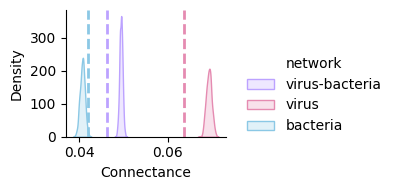

In [9]:
role_palette = {
    'virus-bacteria': "#BCA2FF",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}
g = sns.displot(
    data=null_melt.query('variable == "connectance"'), x='value', kind='kde',  fill=True, height=2.0, aspect=1.25, color='teal', facet_kws={"sharex": True, "sharey": True}, 
    hue='network', palette=role_palette
)
g.set_xlabels("Connectance")
for i, network in enumerate(['virus-bacteria', 'virus', 'bacteria']):
    g.axes[0, 0].axvline(observed.query('Metric == "connectance"').set_index('network').loc[network]['Value'], color=role_palette[network], linewidth=2.0, linestyle='--')
# # #g.axes[0, 0].axvline(observed.set_index('Metric').loc['modularity Q']['Value'], color='red', linewidth=1.0, linestyle='--')
g.savefig("figures/displot.network-metrics.connectance.svg")

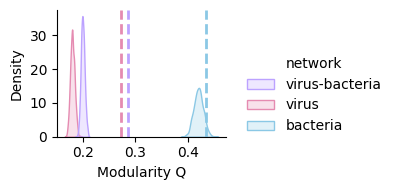

In [10]:
role_palette = {
    'virus-bacteria': "#BCA2FF",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}
g = sns.displot(
    data=null_melt.query('variable == "modularity Q"'), x='value', kind='kde',  fill=True, height=2.0, aspect=1.25, color='teal', facet_kws={"sharex": True, "sharey": True}, 
    hue='network', palette=role_palette
)
g.set_xlabels("Modularity Q")
for i, network in enumerate(['virus-bacteria', 'virus', 'bacteria']):
    g.axes[0, 0].axvline(observed.query('Metric == "modularity Q"').set_index('network').loc[network]['Value'], color=role_palette[network], linewidth=2.0, linestyle='--')
# # #g.axes[0, 0].axvline(observed.set_index('Metric').loc['modularity Q']['Value'], color='red', linewidth=1.0, linestyle='--')
g.savefig("figures/displot.network-metrics.modularity.svg")

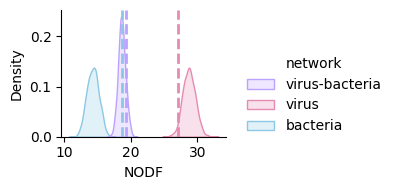

In [11]:
role_palette = {
    'virus-bacteria': "#BCA2FF",
    'virus': "#e58bb1",
    'bacteria': "#8bc8e5",
}
g = sns.displot(
    data=null_melt.query('variable == "NODF"'), x='value', kind='kde',  fill=True, height=2.0, aspect=1.25, color='teal', facet_kws={"sharex": True, "sharey": True}, 
    hue='network', palette=role_palette
)
g.set_xlabels("NODF")
for i, network in enumerate(['virus-bacteria', 'virus', 'bacteria']):
    g.axes[0, 0].axvline(observed.query('Metric == "NODF"').set_index('network').loc[network]['Value'], color=role_palette[network], linewidth=2.0, linestyle='--')
# # #g.axes[0, 0].axvline(observed.set_index('Metric').loc['modularity Q']['Value'], color='red', linewidth=1.0, linestyle='--')
g.savefig("figures/displot.network-metrics.nestedness.svg")

In [12]:
db.conn.close()
si.conn.close()